In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
data = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/Heart.csv")
data.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    int64  
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    object 
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    object 
 14  AHD         303 non-null    object 
dtypes: float64(2), int64(10), object(3)
memory usage: 35.6+ KB


In [62]:
data.drop('Unnamed: 0',axis = 1,inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


In [63]:
data.dropna(inplace = True)

In [64]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


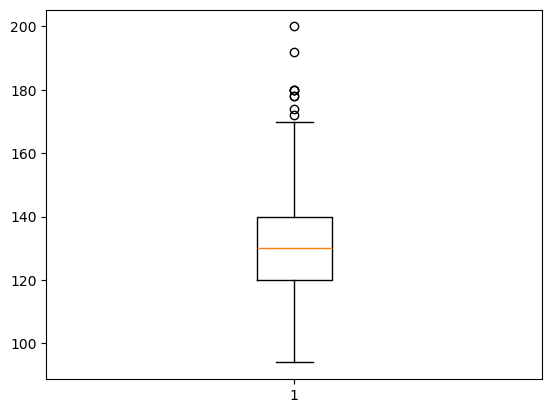

In [65]:
plt.boxplot(data['RestBP'])
plt.show()

###### write a function to find outliers using boxplot(iqr) and histograms (3 sigma rule).with subplot 

In [66]:
def findOutlier(data,column):
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    iqr_outliers = data[(data[column] > upper_bound) | (data[column] < lower_bound)]

    mean = data[column].mean()
    std = data[column].std()
    upper_sigma = mean + 3 * std
    lower_sigma = mean - 3 * std
    sigma_outliers = data[(data[column] > upper_sigma) | (data[column] < lower_sigma)]

    plt.figure(figsize = (14,5))
    plt.subplot(1,2,1)
    plt.boxplot(data[column])
    plt.title("Boxplot")
    plt.ylabel(column)

    plt.subplot(1,2,2)
    plt.hist(data[column],edgecolor='black')
    plt.axvline(lower_sigma, color='red', linestyle='--', label='Lower Bound')
    plt.axvline(upper_sigma, color='red', linestyle='--', label='Upper Bound')
    plt.title("Histogram")
    plt.xlabel(column)

    plt.show()

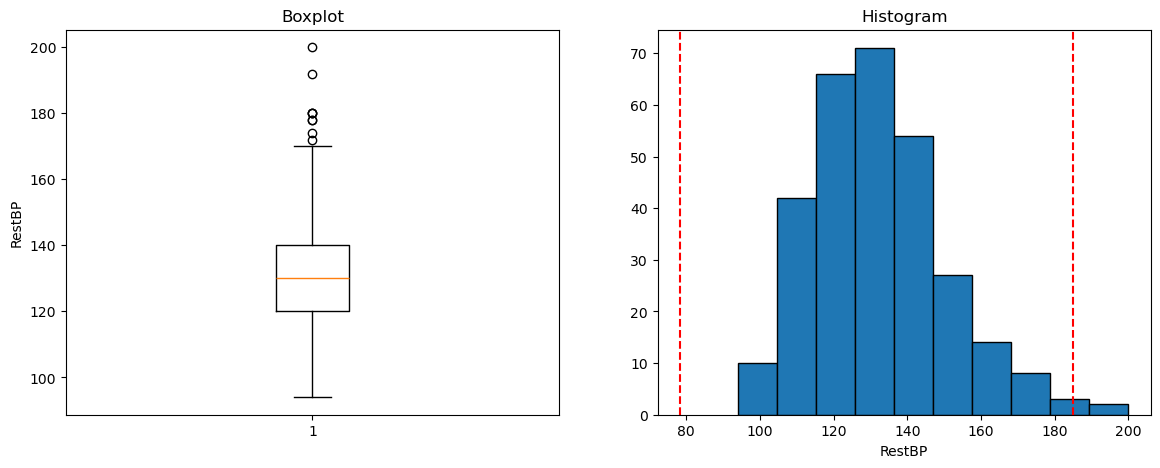

In [67]:
findOutlier(data,'RestBP')

In [68]:
def showOutlier(data,column):
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return data[(data[column] > upper_bound) | (data[column] < lower_bound)]

In [69]:
showOutlier(data,'RestBP')

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
14,52,1,nonanginal,172,199,1,0,162,0,0.5,1,0.0,reversable,No
83,68,1,nonanginal,180,274,1,2,150,1,1.6,2,0.0,reversable,Yes
126,56,0,asymptomatic,200,288,1,2,133,1,4.0,3,2.0,reversable,Yes
172,59,0,asymptomatic,174,249,0,0,143,1,0.0,2,0.0,normal,Yes
183,59,1,typical,178,270,0,2,145,0,4.2,3,0.0,reversable,No
188,54,1,nontypical,192,283,0,2,195,0,0.0,1,1.0,reversable,Yes
201,64,0,asymptomatic,180,325,0,0,154,1,0.0,1,0.0,normal,No
213,66,0,asymptomatic,178,228,1,0,165,1,1.0,2,2.0,reversable,Yes
231,55,0,asymptomatic,180,327,0,1,117,1,3.4,2,0.0,normal,Yes


In [70]:
def handleOutlier(data,column):
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    data.loc[(data[column] > upper_bound),column] = upper_bound
    data.loc[(data[column] < upper_bound),column] = lower_bound

In [71]:
handleOutlier(data,'RestBP')

In [72]:
showOutlier(data,'RestBP')

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
14,52,1,nonanginal,170,199,1,0,162,0,0.5,1,0.0,reversable,No
68,59,1,asymptomatic,170,326,0,2,140,1,3.4,3,0.0,reversable,Yes
83,68,1,nonanginal,170,274,1,2,150,1,1.6,2,0.0,reversable,Yes
126,56,0,asymptomatic,170,288,1,2,133,1,4.0,3,2.0,reversable,Yes
141,59,1,typical,170,288,0,2,159,0,0.2,2,0.0,reversable,Yes
172,59,0,asymptomatic,170,249,0,0,143,1,0.0,2,0.0,normal,Yes
183,59,1,typical,170,270,0,2,145,0,4.2,3,0.0,reversable,No
188,54,1,nontypical,170,283,0,2,195,0,0.0,1,1.0,reversable,Yes
201,64,0,asymptomatic,170,325,0,0,154,1,0.0,1,0.0,normal,No
213,66,0,asymptomatic,170,228,1,0,165,1,1.0,2,2.0,reversable,Yes


In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [74]:
data = pd.get_dummies(data,columns=['ChestPain', 'Thal'],dtype=int)

In [75]:
data.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable
0,63,1,90,233,1,2,150,0,2.3,3,0.0,No,0,0,0,1,1,0,0
1,67,1,90,286,0,2,108,1,1.5,2,3.0,Yes,1,0,0,0,0,1,0
2,67,1,90,229,0,2,129,1,2.6,2,2.0,Yes,1,0,0,0,0,0,1
3,37,1,90,250,0,0,187,0,3.5,3,0.0,No,0,1,0,0,0,1,0
4,41,0,90,204,0,2,172,0,1.4,1,0.0,No,0,0,1,0,0,1,0


In [76]:
X = data.drop('AHD', axis=1)
y = data['AHD']

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 10)